In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

# Add project root so src package imports work from scripts/
sys.path.insert(0, os.path.abspath('..'))

from src.secore_loader import build_h10_ibi_rmssd_xarray_auto
from src.secore_utils import (
    export_h10_to_secore_ncdf,
    save_secore_QC_figures,
    SECORE_EVENT_COLORS,
    sec_ms_str_to_float,
)
import matplotlib.pyplot as plt
%matplotlib widget


## Dyads with problems:
Failed dyads:
  - W_002: Cannot align to stage 2: no samples with stage == 2 found in one or both channels. # JZ H10 signal has strong artifacts -> heavily corrected ; not very reliable
  - W_004: Cannot align to stage 2: no samples with stage == 2 found in one or both channels. # JZ seems OK after adjustment to search only at the end of recording session for alligment
  - W_013: Cannot align to stage 2: no samples with stage == 2 found in one or both channels. # JZ OK , but artifacts during puzzle
  - W_019: Cannot align to stage 2: no samples with stage == 2 found in one or both channels. # JZ OK
  - W_029: Cannot align to stage 2: no samples with stage == 2 found in one or both channels. # JZ OK
  - W_035: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_038: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_039: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_040: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_041: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_042: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_043: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_044: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_048: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_049: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_057: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_072: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_075: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
  - W_078: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.

  - W_018: More than 2 talks detected, something is wrong.
  - W_025: More than 2 talks detected, something is wrong.
  - W_045: More than 2 talks detected, something is wrong.
  - W_073: More than 2 talks detected, something is wrong.
  - W_074: No paired H10 IBI files found for W_074 in /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_RAW_DATA/W_074/eeg

### Informacja od Weroniki:
Diady, które na pewno można wykluczyć z takiego automatycznego eksportu, bo nie miały eeg lub h10 wg Warsaw IDs, to:
-  6,7,8,10,11,33,46,47,79,90,93,96 (na czerwono nie mają obu modalności)
   - W_006: integer division or modulo by zero
   - W_007: single positional indexer is out-of-bounds
   - W_010: Cannot align to stage 2: no samples with stage == 2 found in one or both channels.
   - W_011: No paired H10 IBI files found for W_011 in /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_RAW_DATA/W_011/eeg
   - W_047: No paired H10 IBI files found for W_047 in /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_RAW_DATA/W_047/eeg


-  Dodatkowo diada 3 ma h10 tylko od dziecka, a 92 ma eeg zapisane w dwóch plikach (wywaliło się nagrywanie w trakcie).
   - W_003: too many indices for array: array is 1-dimensional, but 2 were indexed
```
not_complete_dyads = ['W_003','W_006','W_007','W_008','W_010','W_011',
                      'W_033','W_046','W_047','W_079','W_090','W_093','W_096']
```

In [2]:
# ── Dyad identification ──────────────────────────────────────────────────────
DYAD_NR = '035'

In [3]:
input_folder = "/Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_RAW_DATA"
export_folder = "/Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported"
input_synchronization_data = os.path.join(input_folder, "timings_secore_hrv.csv")


# Build settings
# plot_flag = False
fs_ibi = 8
window_size_rmssd_s = 30
decimate_factor_loader = 8
decimate_factor_align = 16
selected_time = (0, 220)

In [4]:
metadata_file = os.path.join(input_folder, "meta_data.csv")
metadata_df = pd.read_csv(metadata_file, sep=';')
synchronization_df = pd.read_csv(input_synchronization_data, sep=',')


In [5]:

dyad = f"W_{DYAD_NR}"
DEV_CG  = 'A839C92B'   # Caregiver H10 device ID
DEV_CH  = 'A83E1E24'   # Child H10 device ID


In [6]:
sync_row = synchronization_df.loc[synchronization_df['id'] == dyad]

if sync_row.empty:
    print(f"Skipping {dyad}: dyad synchronization is yet unavailable")


check_value = pd.to_numeric(sync_row['checked'], errors='coerce').iat[0]
if check_value != 1:
    print(f"Skipping {dyad}: dyad synchronization is yet unavailable")


video_timings = {
    "T1": float(sec_ms_str_to_float(sync_row['T1'].iat[0])),
    "T2": float(sec_ms_str_to_float(sync_row['T2'].iat[0])),
    "T3": float(sec_ms_str_to_float(sync_row['T3'].iat[0])),
    "T4": float(sec_ms_str_to_float(sync_row['T4'].iat[0])),
}
print(f"Video timings for {dyad}: {video_timings}")

Video timings for W_035: {'T1': 76.255, 'T2': 172.727, 'T3': 709.468, 'T4': 837.805}


# Load the H10 data:
- load
- sychronize them using the ECG during watching movies, 
- compute IBI and RMSSD for the SECORE part of the experyment based on the H10 signals


Auto-detected latest recording for W_35: None None, CH=A83E1E24, CG=A839C92B
Detected events: {'Brave': {'name': 'Brave', 'start': 35.39453125, 'duration': 59.314453125}, 'Peppa': {'name': 'Peppa', 'start': 174.3564453125, 'duration': 59.61328125}, 'Incredibles': {'name': 'Incredibles', 'start': 104.92578125, 'duration': 59.197265625}, 'Talk_1': {'name': 'Talk_1', 'start': 326.10546875, 'duration': 181.0556640625}, 'Talk_2': {'name': 'Talk_2', 'start': 589.595703125, 'duration': 181.0400390625}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Brave
No ET_event found, using EEG_events data only.
Events column created based on EEG_events and ET_event columns.
Event structure created based on events column.

Event Name                     Start (s)       Duration (s)   
Brave                          0.00            59.30          
Incredibles                    69.54           59.19          
Peppa                          138.96          59.61          
Talk_1   

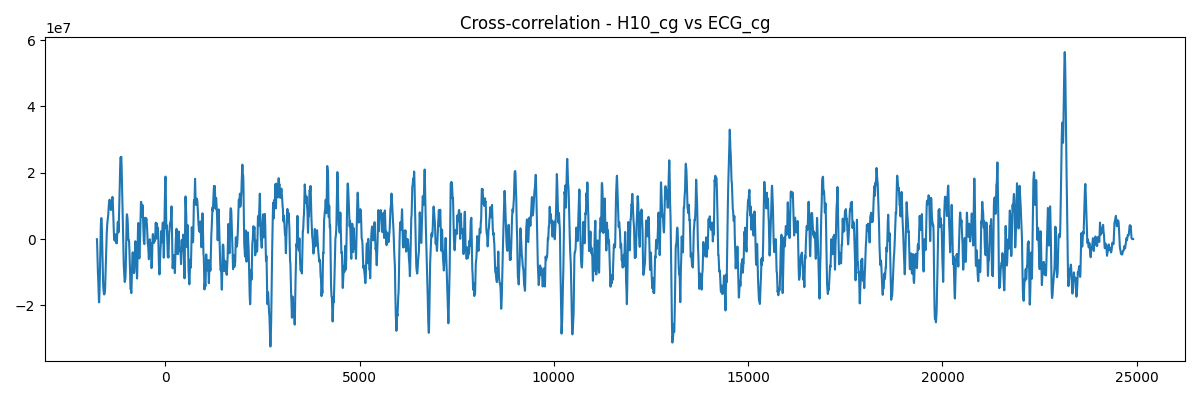

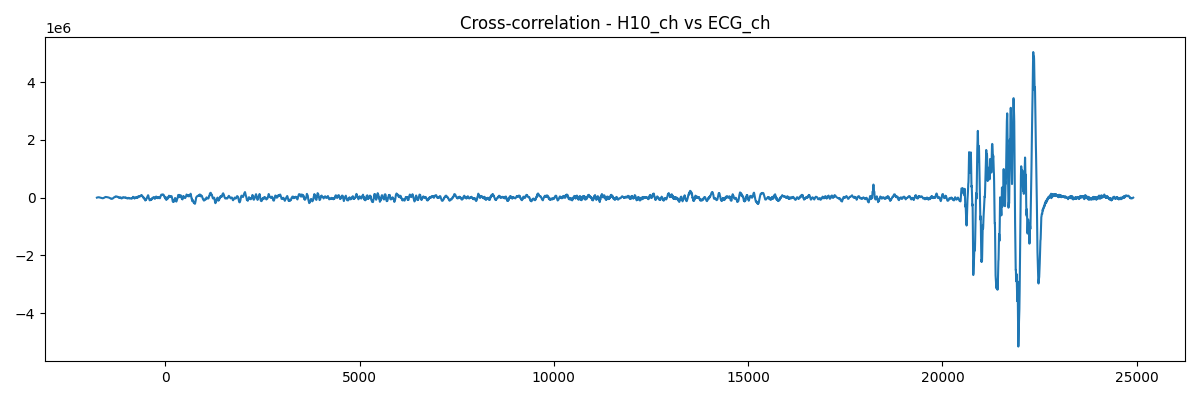

Computed lags (in seconds) to ECG: CG=2893.375, CH=2792.125


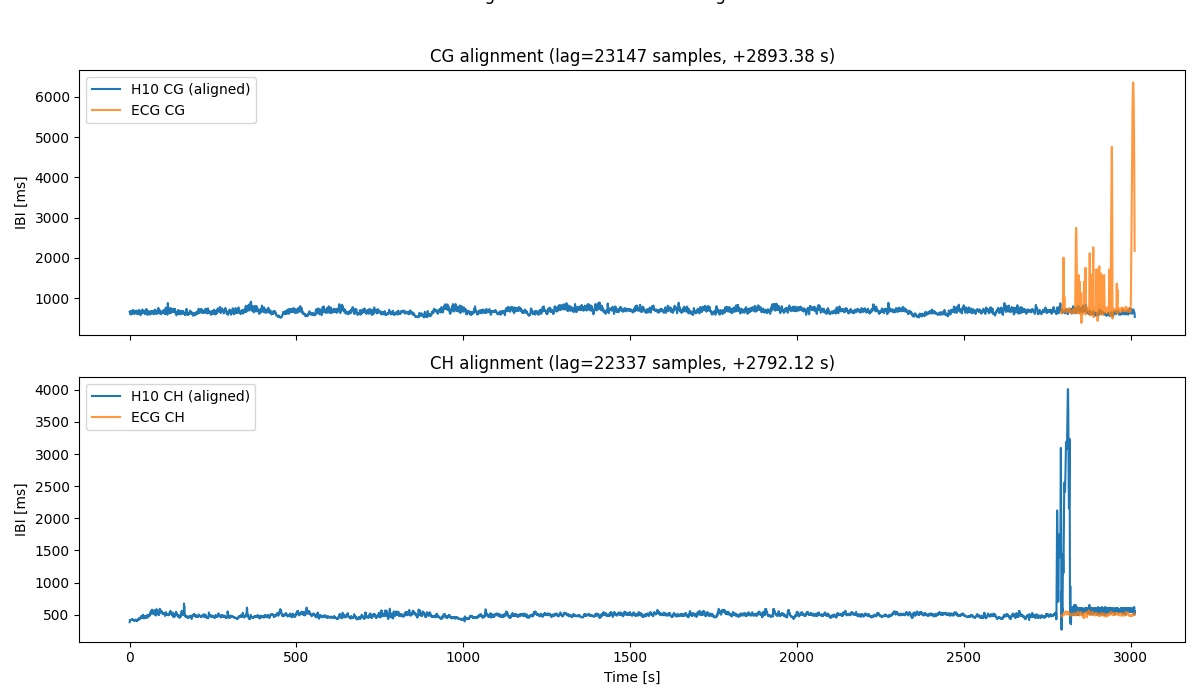

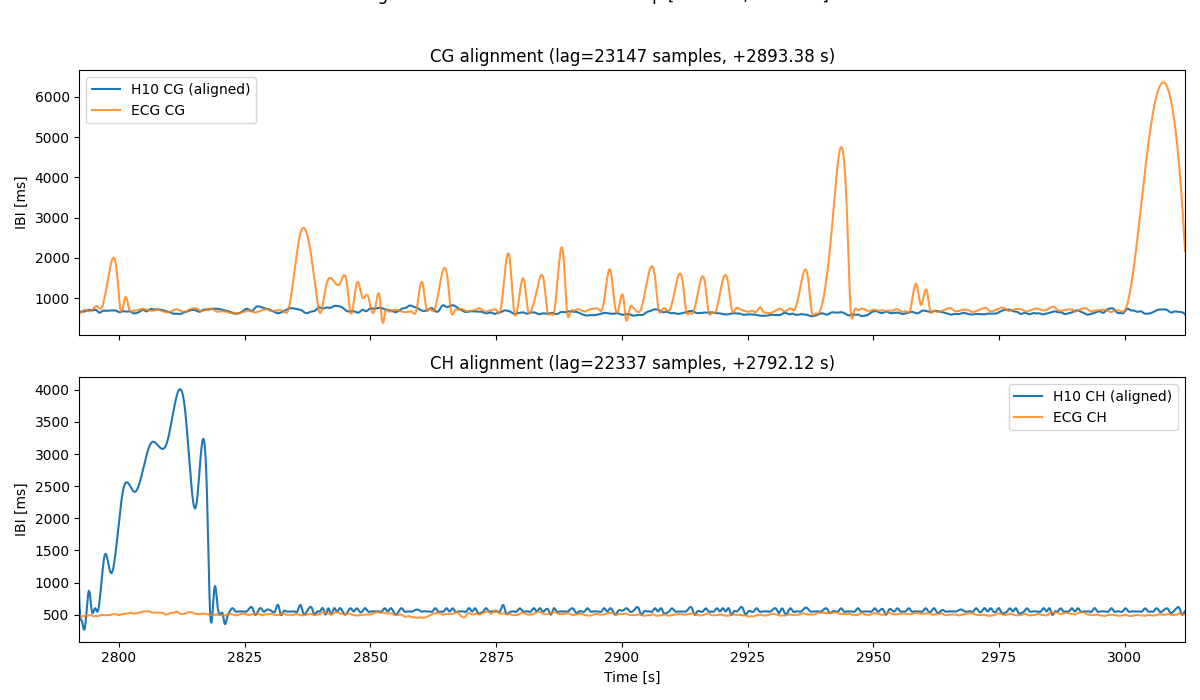

<xarray.DataArray 'H10_IBI_RMSSD_events' (time: 24100, channel: 5)> Size: 964kB
array([[383.39738682, 656.77914846,   0.9765625 ,  43.30576074,
          0.        ],
       [395.69145422, 653.47922539,   0.9765625 ,  43.30576074,
          0.        ],
       [404.64792599, 651.67395944,   0.9765625 ,  43.30576074,
          0.        ],
       ...,
       [558.97606917, 579.29176289,  39.64526419,  34.51759461,
          0.        ],
       [558.10962946, 557.81365467,  40.03112218,  34.51759461,
          0.        ],
       [553.89255162, 532.52090776,  40.03112218,  34.51759461,
          0.        ]], shape=(24100, 5))
Coordinates:
  * time     (time) float64 193kB 0.0 0.125 0.25 ... 3.012e+03 3.012e+03
  * channel  (channel) <U8 160B 'IBI_CH' 'IBI_CG' 'RMSSD_CH' 'RMSSD_CG' 'events'
Attributes: (12/13)
    sampling_frequency_Hz:  8
    dyad_id:                W_035
    window_size_RMSSD_s:    30
    device_CH:              A83E1E24
    device_CG:              A839C92B
    recordi

In [7]:
# One-line call: only dyad number (with notebook-level preferred device IDs)
dyad_nr = int(dyad.split('_')[1])
synch_time = video_timings["T1"]
h10_xarray = build_h10_ibi_rmssd_xarray_auto(
    dyad_nr=dyad_nr,
    video_timings=video_timings,
    data_base_path=input_folder,
    fs_ibi=fs_ibi,
    window_size_rmssd_s=window_size_rmssd_s,
    decimate_factor_loader=decimate_factor_loader,
    decimate_factor_align=decimate_factor_align,
    selected_time=selected_time,
    plot=True,
    preferred_dev_ch=DEV_CH,
    preferred_dev_cg=DEV_CG,
)
print(h10_xarray)
print(f'\nshape: {h10_xarray.shape}')
print(f'sampling_frequency_Hz: {h10_xarray.attrs["sampling_frequency_Hz"]}')


# Export ot ncdf format

In [8]:
dyad_id = f"W_{str(DYAD_NR).zfill(3)}"
export_root = Path(export_folder)

saved_files = export_h10_to_secore_ncdf(
    h10_xarray=h10_xarray,
    dyad_id=dyad_id,
    export_root=export_root,
)

print("Saved Secore NetCDF files:")
for p in saved_files:
    print(f"- {p}")


Saved Secore NetCDF files:
- /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported/Secore_IBI/W_035/child/W_035_IBI_ch_Secore.nc
- /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported/Secore_IBI/W_035/caregiver/W_035_IBI_cg_Secore.nc
- /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported/Secore_RMSSD/W_035/child/W_035_RMSSD_ch_Secore.nc
- /Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_

# Plots of IBI and RMSSD with events marked based on the xarray information

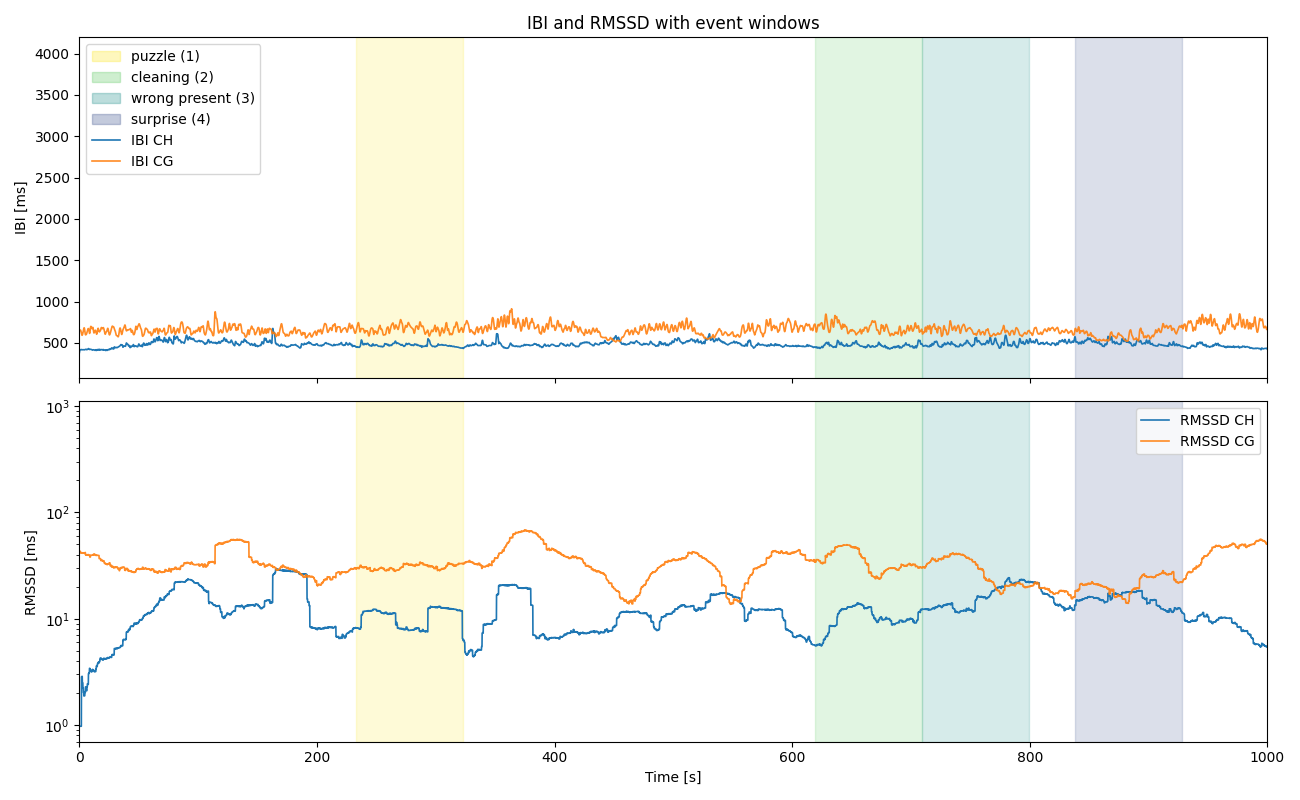

In [9]:
# Extract time axis and channels from xarray
t = h10_xarray.coords['time'].values
ibi_ch = h10_xarray.sel(channel='IBI_CH').values
ibi_cg = h10_xarray.sel(channel='IBI_CG').values
rmssd_ch = h10_xarray.sel(channel='RMSSD_CH').values
rmssd_cg = h10_xarray.sel(channel='RMSSD_CG').values

# Event metadata from attrs
event_code_map = json.loads(h10_xarray.attrs.get('event_code_map_json', '{}'))
event_windows_s = json.loads(h10_xarray.attrs.get('event_windows_s_json', '{}'))

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(13, 8))

# IBI panel
axes[0].plot(t, ibi_ch, label='IBI CH', lw=1.2)
axes[0].plot(t, ibi_cg, label='IBI CG', lw=1.2, alpha=0.9)
axes[0].set_ylabel('IBI [ms]')
axes[0].set_title('IBI and RMSSD with event windows')

# RMSSD panel
axes[1].semilogy(t, rmssd_ch, label='RMSSD CH', lw=1.2)
axes[1].semilogy(t, rmssd_cg, label='RMSSD CG', lw=1.2, alpha=0.9)
axes[1].set_ylabel('RMSSD [ms]')
axes[1].set_xlabel('Time [s]')

# Shade event windows on both axes
for event_name, window in event_windows_s.items():
    if event_name == 'baseline':
        continue
    start = float(window['start_s'])
    end = float(window['end_s'])
    color = SECORE_EVENT_COLORS.get(event_name, '#bbbbbb')
    for ax in axes:
        ax.axvspan(start, end, color=color, alpha=0.18)

# Build combined signal + event legend
event_handles = []
for event_name, code in sorted(event_code_map.items(), key=lambda kv: kv[1]):
    if event_name == 'baseline':
        continue
    color = SECORE_EVENT_COLORS.get(event_name, '#bbbbbb')
    event_handles.append(plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.3, label=f'{event_name} ({code})'))

signal_handles_0 = axes[0].get_legend_handles_labels()[0]
axes[0].legend(handles=event_handles + signal_handles_0, loc='upper left')
axes[1].legend(loc='upper right')

axes[0].set_xlim(0, 1000)
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()


# Compare the same plots for the  data loaded from ncdf files

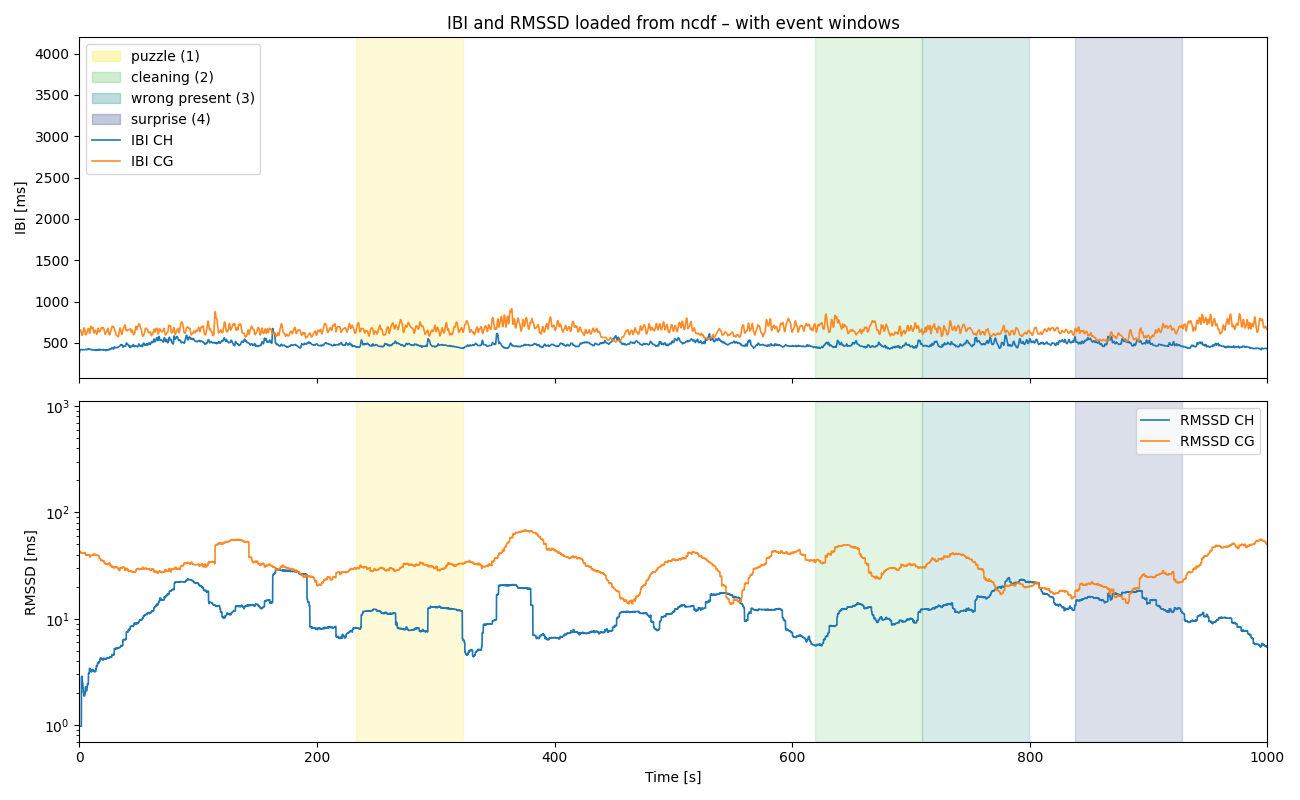

In [10]:
save_secore_QC_figures(dyad_id=dyad_id, export_root=export_root)


## RMSSD in Short (~30s) Time Windows
RMSSD (Root Mean Square of Successive Differences) is the square root of the mean of squared differences between consecutive RR intervals. In short windows, it is the standard proxy for vagal (parasympathetic) modulation of heart rate.

### What it reflects physiologically
- RMSSD captures high-frequency beat-to-beat variability, which is almost exclusively driven by the vagus nerve acting on the sinoatrial node via acetylcholine. 
- Sympathetic influence operates too slowly (several seconds of latency) to meaningfully affect successive-beat differences, so RMSSD is considered sympathetically insensitive at short timescales — a key advantage over measures like SDNN or LF/HF power.
- In practical terms, high RMSSD → strong vagal tone → greater cardiac parasympathetic activity.

### Validity in ~30s windows
The standard recommendation (Task Force 1996) is 5-minute windows for reliable HRV. However, 30s RMSSD is empirically well-validated:

It correlates very strongly (r > 0.9) with 5-min RMSSD across many populations
It is the basis of ultra-short HRV research (Esco, Flatt, and colleagues), which showed that 1-min windows are generally sufficient, and 30s windows are usable with caution
The key limitation is stationarity — 30s may capture fewer than ~30 beats at rest, making the estimate noisier, especially if there are ectopic beats or motion artifacts


### What 30s RMSSD tells you in practice


- Resting baseline: Tonic vagal tone; high values indicate good autonomic health
- Post-stimulus (e.g., cognitive load, stress): Rapid vagal withdrawal is detectable within seconds — RMSSD drops fast
- Recovery monitoring (exercise, stress): Vagal reactivation speed; RMSSD recovers faster in fit/healthy individuals